<a href="https://colab.research.google.com/drive/1tElT3FhddabqCyJKFH27rhnyXJTqrzke?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K Nearest Neighbors (KNN)

# Homework

The quality of classification/regression by the k Nearest Neighbors method depends on several parameters:
* the number of neighbors `n_neighbors`
* the distance metric between objects `metric`
* the weights of neighbors (the neighbors of the test example can enter with different weights, for example, the further the example, the less its "voice" is taken into account) `weights`


Train the `KNeighborsClassifier` on the dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from google.colab import drive
drive.mount('/content/drive')

all_data = pd.read_csv("/content/drive/MyDrive/forest_dataset.csv", low_memory=False)

all_data.head()

Mounted at /content/drive


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


In [ ]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(feature_matrix,labels, test_size=0.2, random_state=111)

print('Train size:', train_feature_matrix.shape)
print('Test size: ', test_feature_matrix.shape)

Train size: (8000, 54)
Test size:  (2000, 54)


In [ ]:
log_reg = LogisticRegression(C=1, max_iter=500, solver='saga')

log_reg.fit(train_feature_matrix, train_labels)

log_pred = log_reg.predict(test_feature_matrix)

log_reg_accuracy = accuracy_score(test_labels, log_pred)

print("Log reg accuracy:", log_reg_accuracy)

Log reg accuracy: 0.6535


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


clf = KNeighborsClassifier()
clf.fit(train_feature_matrix, train_labels)


y_pred_base = clf.predict(test_feature_matrix)
base_accuracy = accuracy_score(test_labels, y_pred_base)
print(f'Accuracy KNN (default, k=5): {base_accuracy:.2}')

Accuracy KNN (default, k=5): 0.73


Let's select the parameters of our model:

* Iterate over the grid from `1` to `10` for the number of neighbors parameter
* Also, try using different metrics: `['manhattan', 'euclidean']`
* Try using different weight calculation strategies: `[‘uniform’, ‘distance’]`

In [48]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors': np.arange(1, 11),'metric': ['manhattan', 'euclidean'],'weights': ['uniform', 'distance'],}

clf = KNeighborsClassifier()
clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

clf_grid.fit(feature_matrix, labels)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['manhattan', 'euclidean'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

Let's output the best parameters

In [ ]:
print(clf_grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': np.int64(4), 'weights': 'distance'}


Using the optimal number of neighbors found, calculate the probabilities of belonging to classes for the test sample (`.predict_proba`).

In [ ]:
best_params = clf_grid.best_params_

optimal_clf = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'], metric=best_params['metric'], weights=best_params['weights'])
optimal_clf.fit(train_feature_matrix, train_labels)


pred_prob = optimal_clf.predict_proba(test_feature_matrix)

print(pred_prob)

[[0.68575246 0.31424754 0.         ... 0.         0.         0.        ]
 [0.50710543 0.49289457 0.         ... 0.         0.         0.        ]
 [0.         1.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.27328414 0.16552003 ... 0.         0.56119583 0.        ]
 [0.42734533 0.57265467 0.         ... 0.         0.         0.        ]
 [1.         0.         0.         ... 0.         0.         0.        ]]


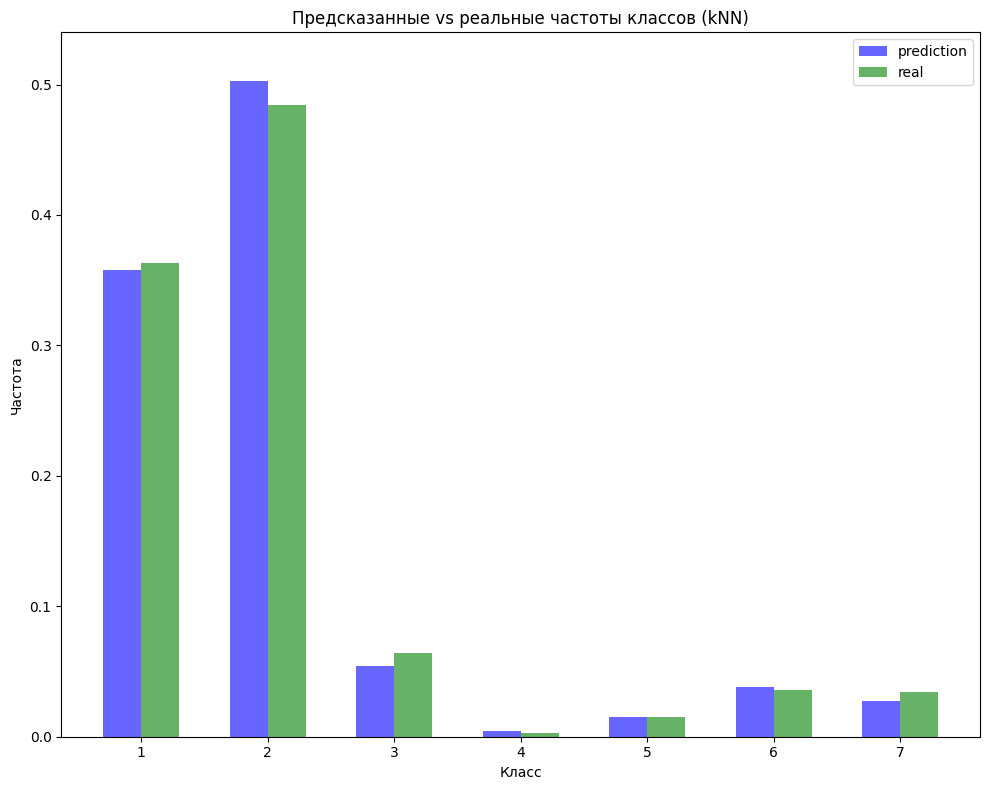

In [ ]:
unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels), freq))

pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=-0.3, align='edge', label='prediction', color='blue', alpha=0.6)
plt.bar(range(1, 8), freq, width=0.3, align='edge', label='real', color='green', alpha=0.6)
plt.ylim(0, 0.54)
plt.xlabel('Класс')
plt.ylabel('Частота')
plt.title('Предсказанные vs реальные частоты классов (kNN)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

y_pred_optimal = optimal_clf.predict(test_feature_matrix)
knn_accuracy = accuracy_score(test_labels, y_pred_optimal)
print(f'Accuracy KNN: {knn_accuracy:.4f}')


logreg = LogisticRegression(C=4, penalty='l1', solver='saga', max_iter=300, random_state=111)
logreg.fit(train_feature_matrix, train_labels)
y_pred_lr = logreg.predict(test_feature_matrix)
lr_accuracy = accuracy_score(test_labels, y_pred_lr)
print(f'Accuracy LogReg (C=4, l1):  {lr_accuracy:.4f}')


Accuracy KNN: 0.7810
Accuracy LogReg (C=4, l1):  0.6425


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


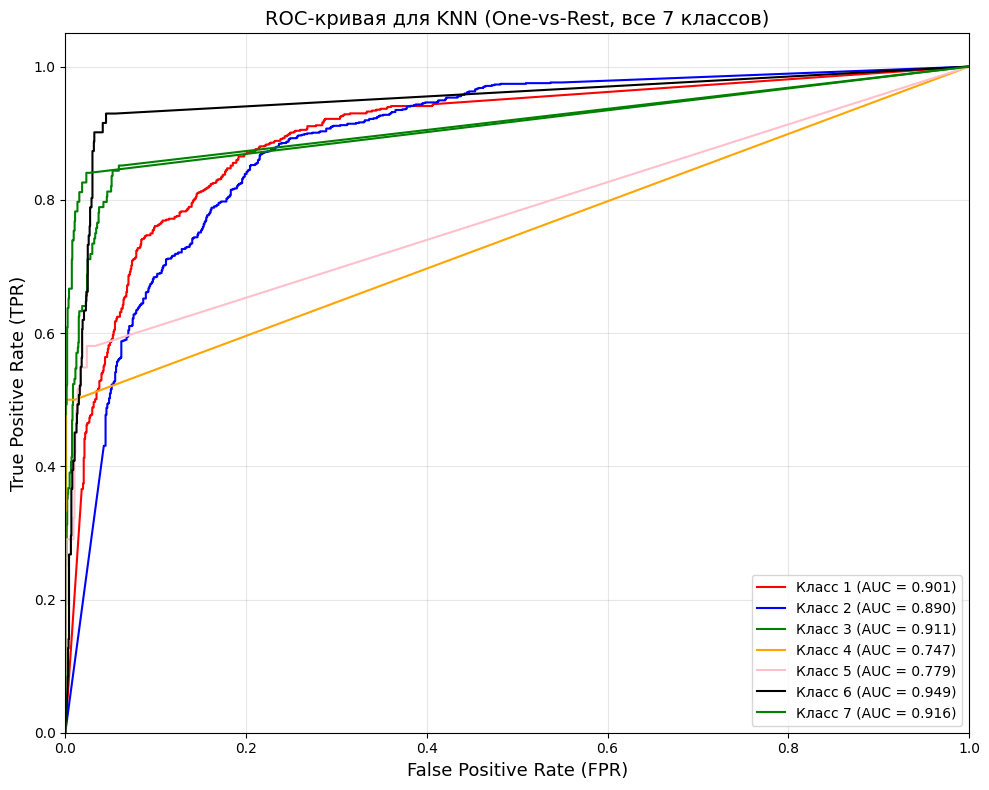

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(labels)
n_classes = len(classes)

test_labels_bin = label_binarize(test_labels, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[cls], tpr[cls], _ = roc_curve(test_labels_bin[:, i], pred_prob[:, i])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])


colors = ['red', 'blue', 'green', 'orange', 'pink', 'black', 'green']

plt.figure(figsize=(10, 8))
for i, cls in enumerate(classes):
    plt.plot(fpr[cls], tpr[cls], color=colors[i], lw=1.5,
             label=f'Класс {cls} (AUC = {roc_auc[cls]:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=13)
plt.ylabel('True Positive Rate (TPR)', fontsize=13)
plt.title('ROC-кривая для KNN (One-vs-Rest, все 7 классов)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

КНН лучше, тк наш датасет содержит различные виды растительности. Логично предоложить, что эти виды будут разбиваться на ярковыраженные классы. КНН хорошо подходит для того, чтобы находить эти классы, в отличии от логрегрессии.

Логичными минусами является скорость работы (я очень устал ждать выполнение...)